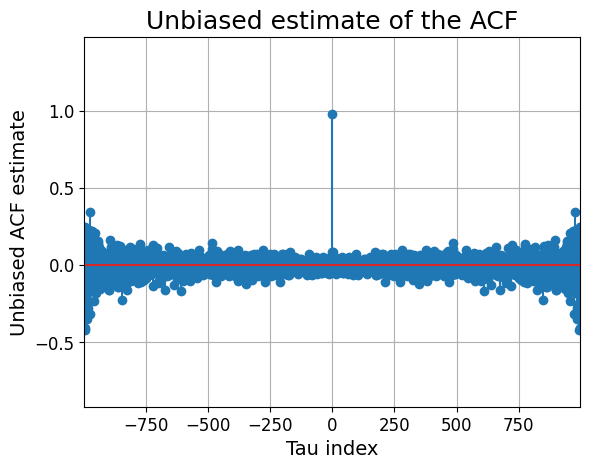

In [12]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'axes.labelsize': 14,
    'axes.titlesize': 18,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

N = 1000
# x = np.random.randn(N)   # WGN realization
rng = np.random.default_rng(42)
x = rng.standard_normal(N)
# Full autocorrelation
r_full = np.correlate(x, x, mode='full')

# Lags
lags = np.arange(-(N-1), N) 

# Unbiased normalization
r_unbiased = r_full / ((N) - np.abs(lags))
plt.figure()
plt.stem(lags, r_unbiased)
plt.axis([-999, 999, np.min(r_unbiased) - 0.5, np.max(r_unbiased) + 0.5])
plt.xlabel("Tau index")
plt.ylabel("Unbiased ACF estimate")
plt.title("Unbiased estimate of the ACF")
plt.grid(True)


We want bias and variance of the estimate to be zero. Mean of the estimate is equal to the parameter and variance of the estimator to be zero. 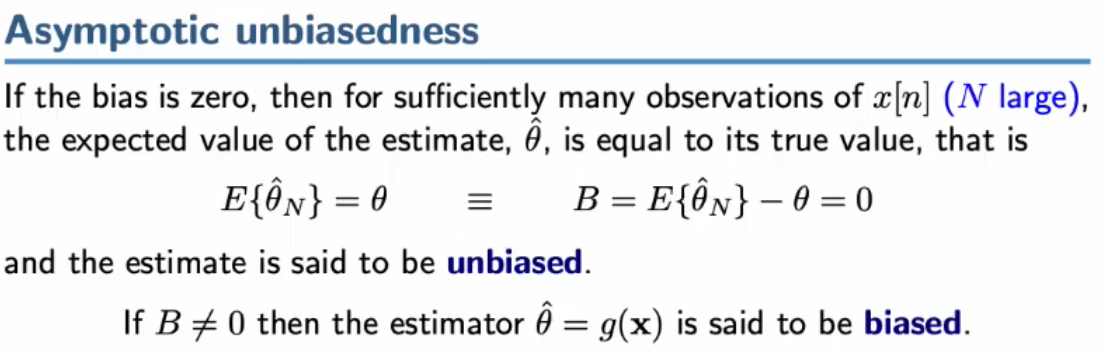
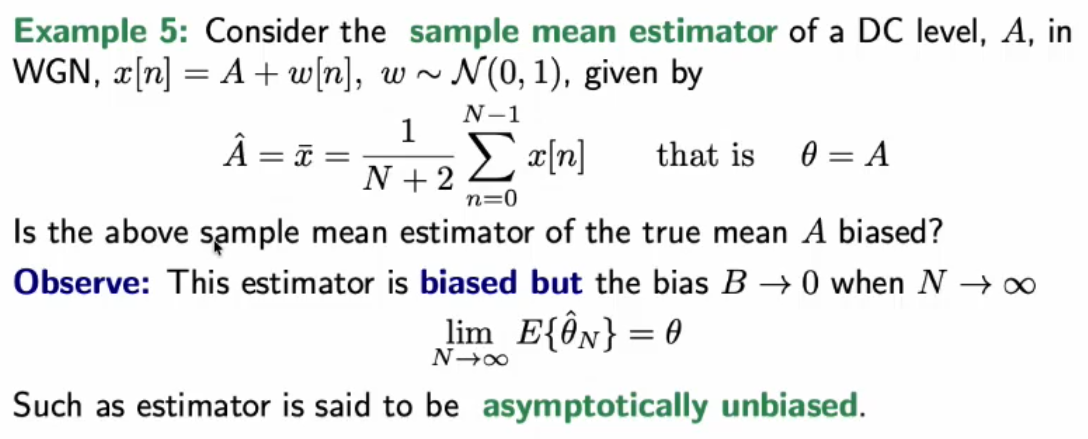

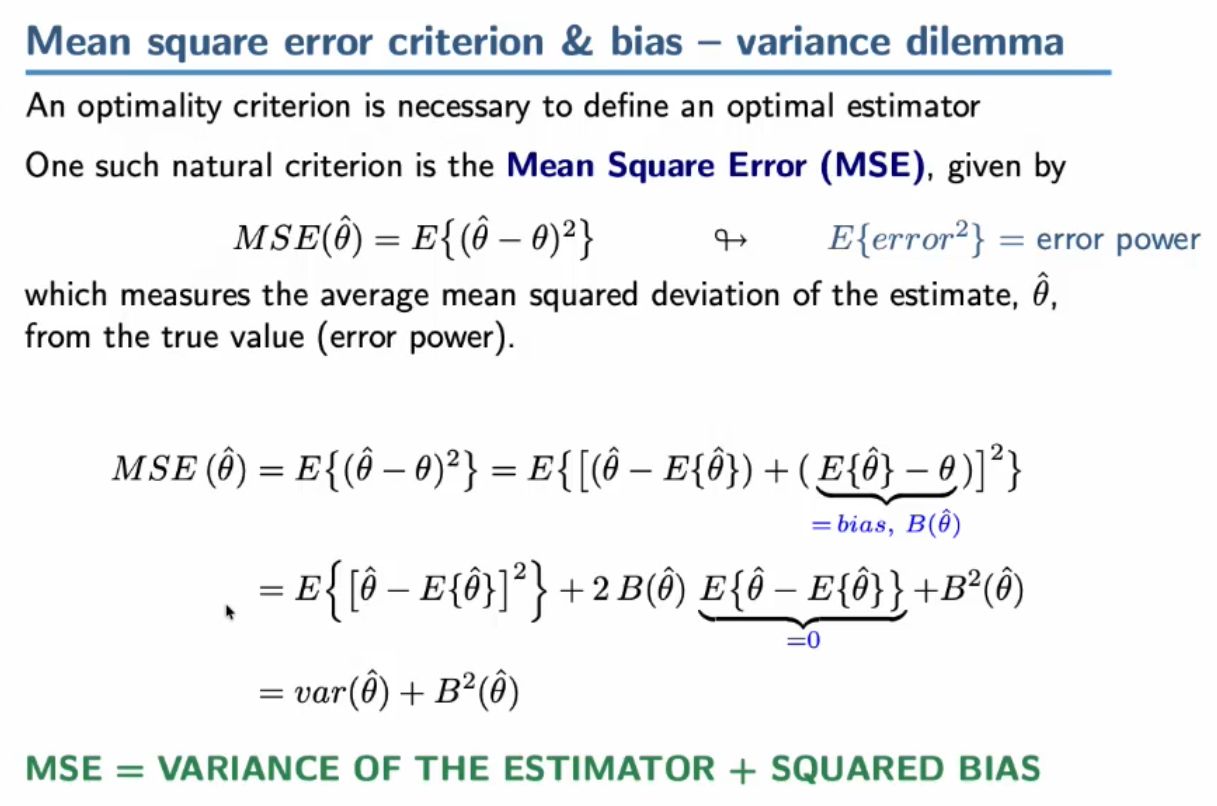

The unbiased estimate of the ACF is not quite what we would expect with the theoretical ACF being a discrete delta function, as this requires an infinite number of samples. The unbiased estimate has an unbiased mean but has non-zero variance for tau != 0. As N increases, the estimate gets closer to the theoretical ACF. The unbiased estimator has correct mean but a high variance. 

Because for lag tau you only have N - |tau| overlapping sample pairs. The unbiased estimator divides by N - |tau|, so as |tau| grows the effective sample size shrinks and the variance blows up. Near |tau| = N-1 you’re averaging just one product, so the estimate is extremely noisy. There is no averaging for larger tau values so the variance is high.

The ACF estimate is even (symmetric about $\tau=0$) for real signals, i.e., $r_{xx}(\tau)=r_{xx}(-\tau)$; small asymmetries are due to finite-sample noise.


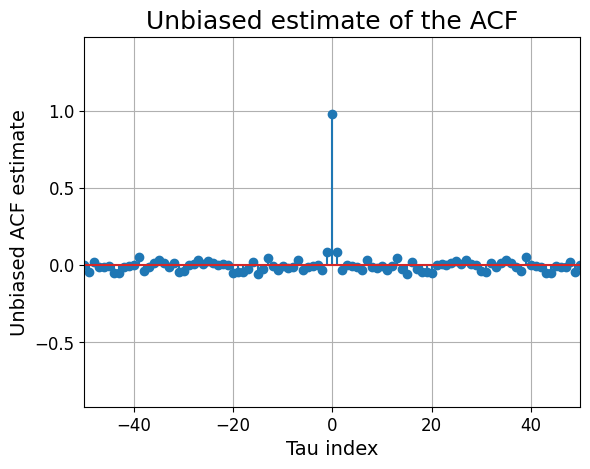

In [13]:
plt.figure()
plt.stem(lags, r_unbiased)
plt.axis([-999, 999, np.min(r_unbiased) - 0.5, np.max(r_unbiased) + 0.5])
plt.xlim(-50, 50)
plt.xlabel("Tau index")
plt.ylabel("Unbiased ACF estimate")
plt.title("Unbiased estimate of the ACF")
plt.grid(True)

For small tau, the unbiased estimate of the ACF behaves more like the ideal discrete delta function. 

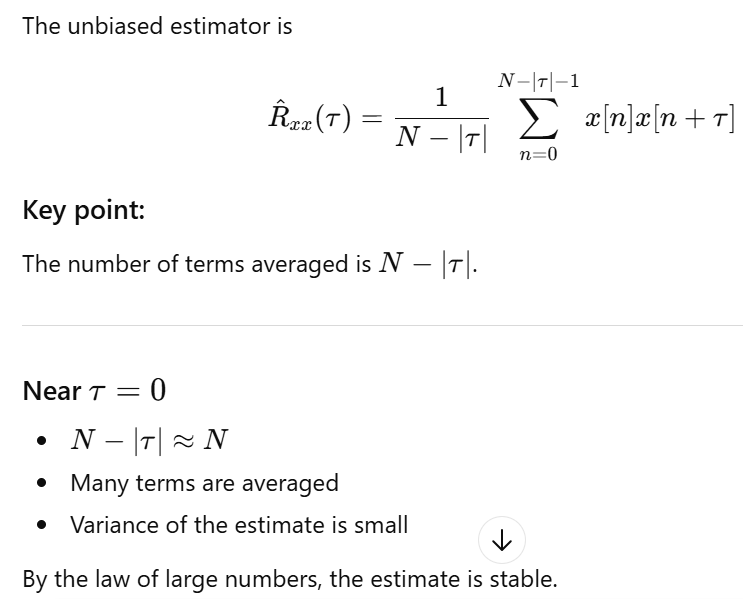

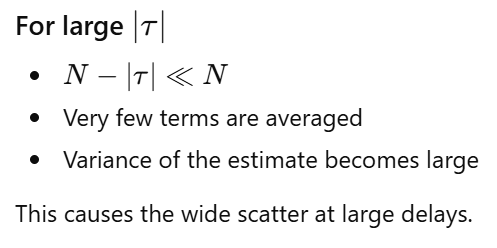

For large autocorrelation lags, the estimate is not statistically reliable. This is an intrinsic limitation of finite-length autocorrelation estimation, especially for the unbiased estimator.

A simple empirical 95% bound for WGN is
$$\hat r_{xx}(\tau) \approx 0 \pm 2\,\sigma_x^2/\sqrt{N-|\tau|}$$
since the variance of the unbiased estimate grows roughly like $\mathrm{Var}[\hat r_{xx}(\tau)] \propto 1/(N-|\tau|)$. As $|\tau|$ increases, fewer products are averaged, so the estimate becomes noisy.
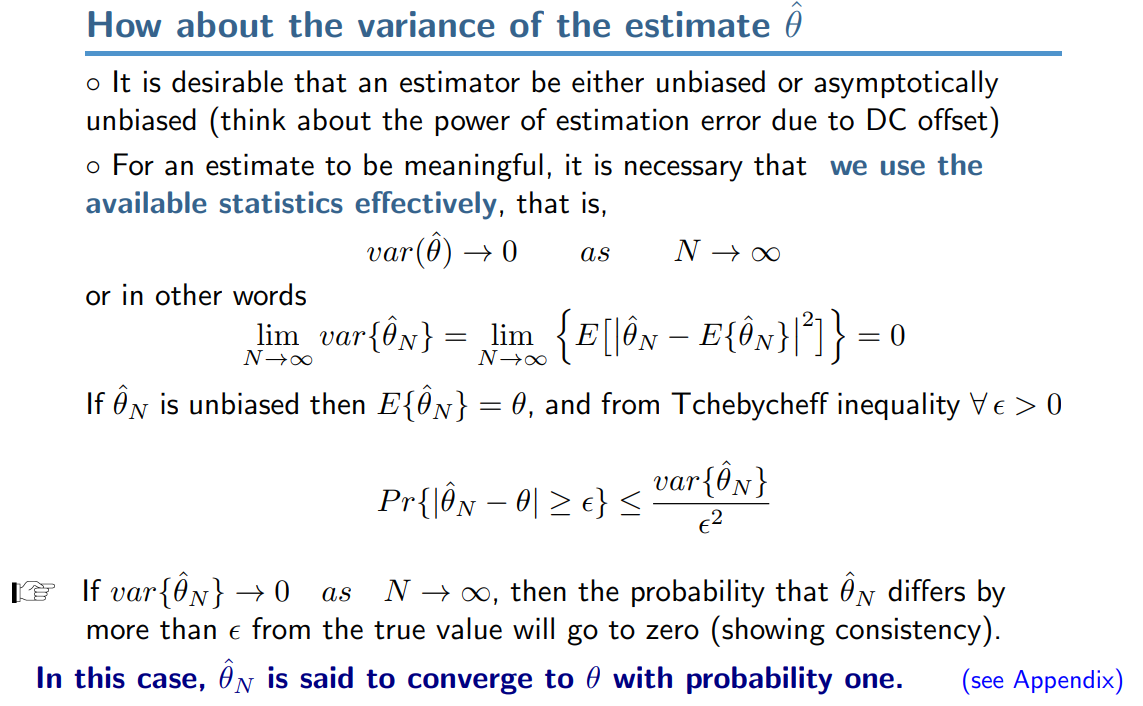
We say that the estimator is consistent if it is asymptotically unbiased
and has a variance that goes to zero as N → ∞
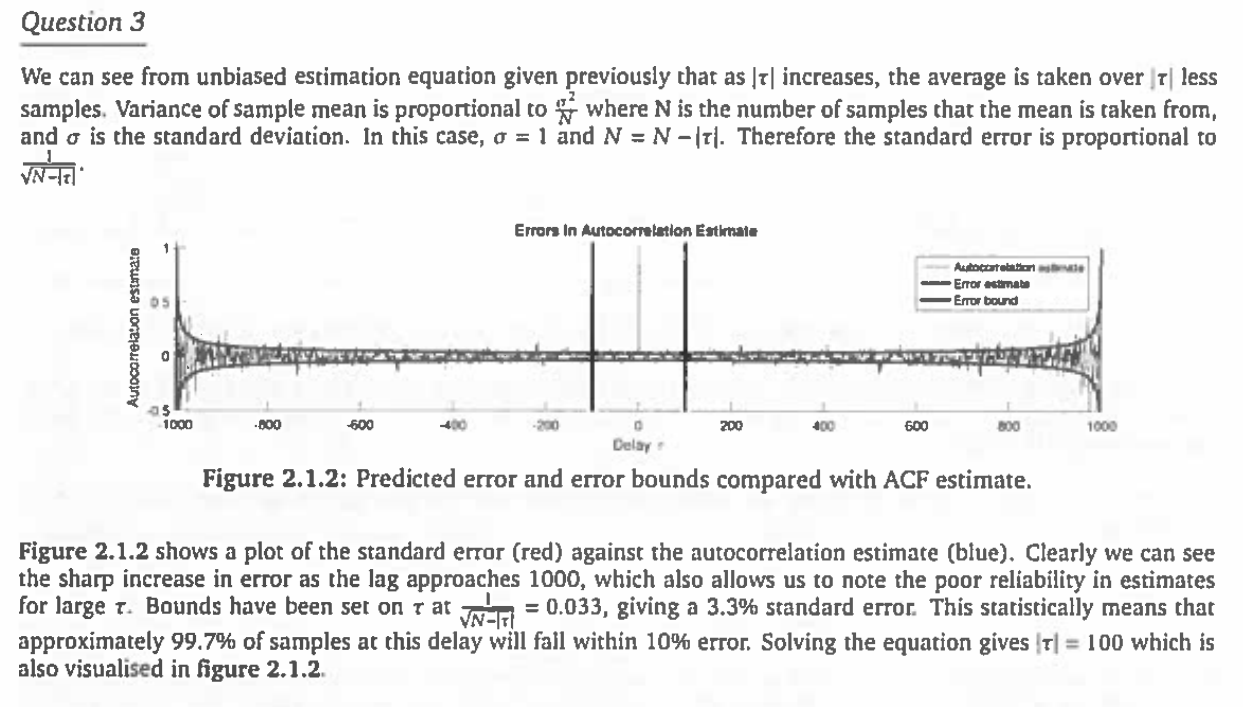

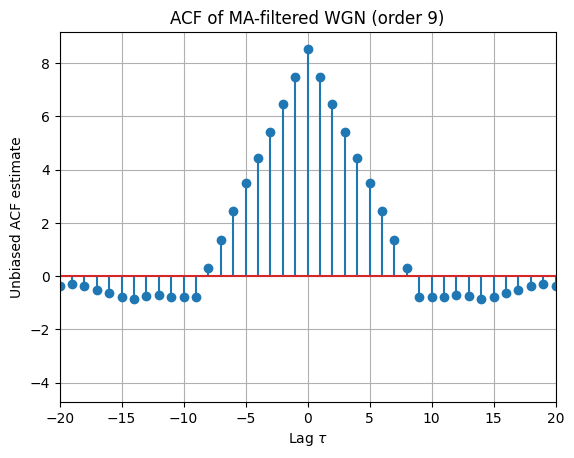

In [10]:
from scipy.signal import lfilter

N = 1000
x = np.random.randn(N)        # WGN
b = np.ones(9)                # MA coefficients
a = [1]

y = lfilter(b, a, x)
r_full = np.correlate(y, y, mode='full')
lags = np.arange(-(N-1), N)
r_unbiased = r_full / (N - np.abs(lags))
plt.figure()
plt.stem(lags, r_unbiased)
plt.xlim(-20, 20)
plt.xlabel(r'Lag $\tau$')
plt.ylabel('Unbiased ACF estimate')
plt.title('ACF of MA-filtered WGN (order 9)')
plt.grid(True)

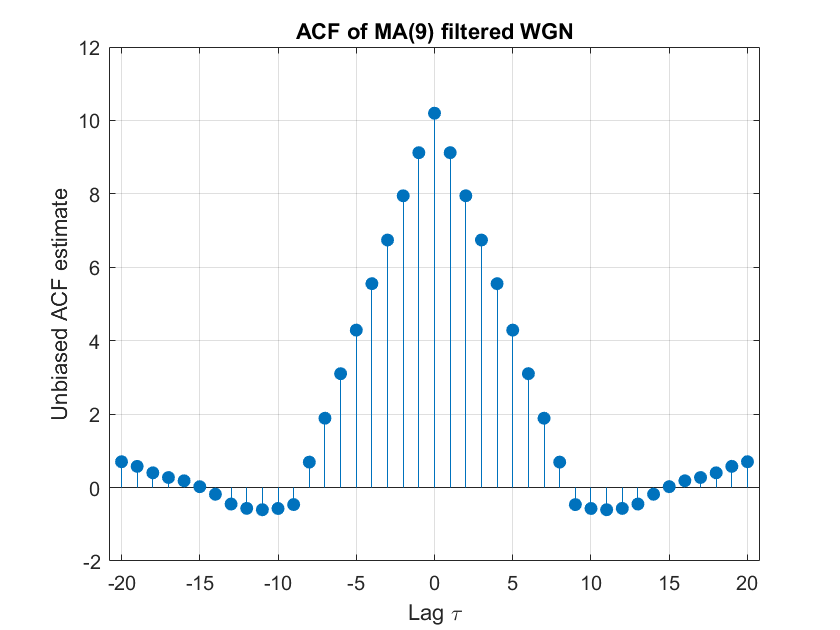

Triangle function for lag values within the moving average filter order. The peak of the triangle function is found at a lag value of 0. As filter order increases, the triangle function gets wider and higher. 
The ACF of MA-filtered WGN is a finite-support sequence with a triangular-like shape. It is the autocorrelation of the filter impulse response (here, a length-9 rectangle), scaled by the input variance. That is why the ACF has its largest value at tau=0 and decreases linearly to zero at |tau| >= 8.
As |τ| increases, the overlap between the two windows shrinks.
Once |τ| ≥ 9, the windows don’t overlap at all, so the ACF goes to (approximately) zero.

Effect of filter order:
Increasing the MA order increases the ACF support (wider base) and smooths the output, so the ACF becomes broader and more triangular.

For WGN input, the output ACF is essentially the autocorrelation of the filter’s impulse response, scaled by the input variance. So the graph directly reflects the MA coefficients: Your MA(9) filter has h[n] = 1 for n = 0..8 (a 9‑tap rectangle).
The autocorrelation of a rectangle is a triangle.
That’s why the ACF is highest at τ=0 and decreases linearly with |τ|, hitting zero at |τ| ≥ 9


Local sample mean:
A moving-average filter computes a local sum (or mean if you divide by 9). It can be used to estimate a local mean (by dividing the value from the filter by the filter order), but it is biased near edges and depends on the window size.


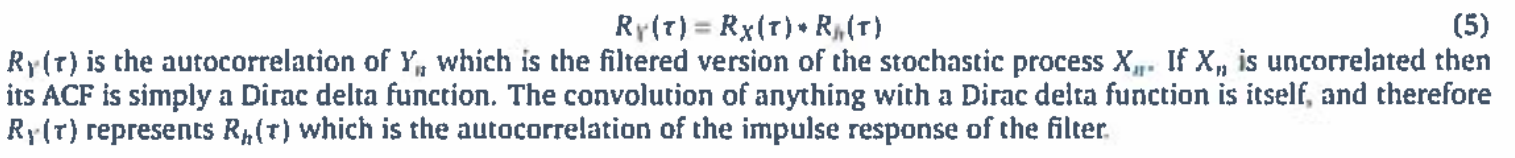

If X_n is uncorrelated (white), then
R_X(τ) = σ_x^2 δ[τ].
So

R_Y(τ) = R_X(τ) * R_h(τ) = σ_x^2 R_h(τ).